<a href="https://colab.research.google.com/github/sakshidubey386-cmyk/Afficionado-Coffee-Roasters/blob/main/Coffee_csv_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Streamlit Web Application **Requirements**

In [6]:
# Install first
!pip install streamlit plotly -q

Core Modules
• Overall sales trend dashboard

• Day-of-week performance charts

• Hourly demand heatmaps

• Location comparison panels

/tmp/ipykernel_1705/689341048.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'transaction_time': pd.date_range("2025-01-01 07:00", periods=n, freq='2H').strftime("%H:%M:%S"),
/tmp/ipykernel_1705/689341048.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["transaction_time"]).dt.hour


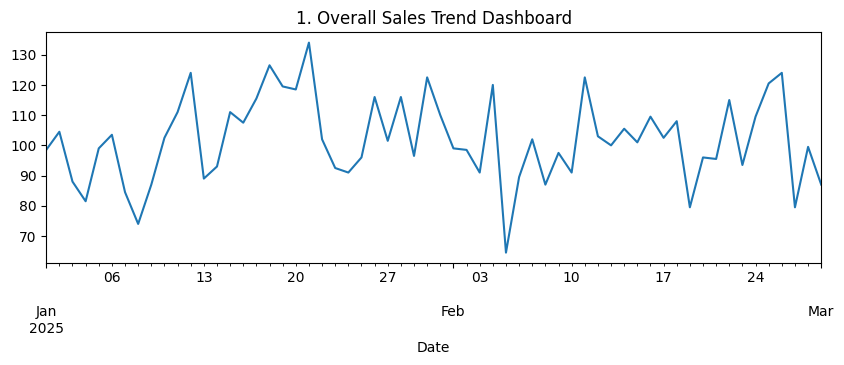

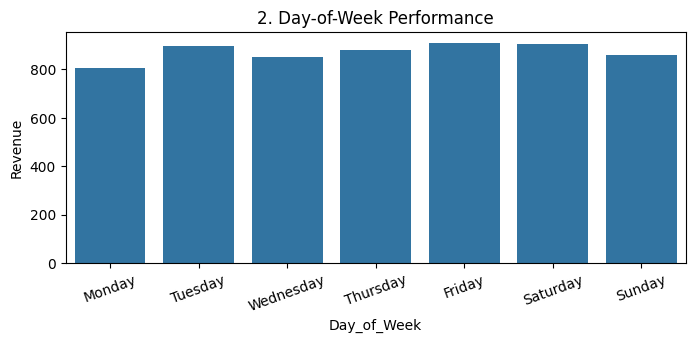

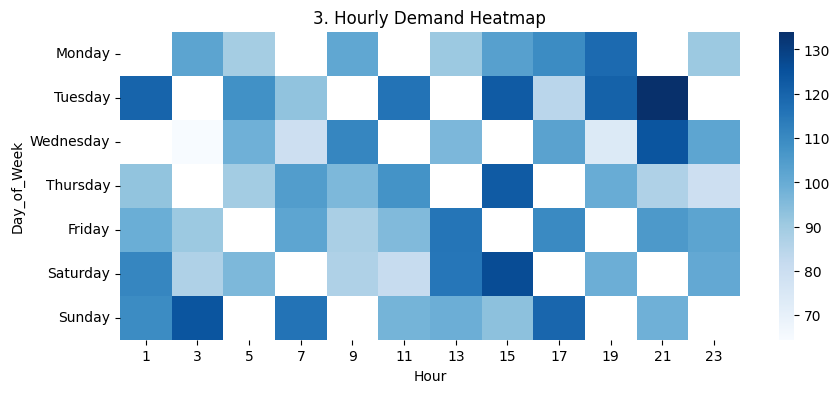

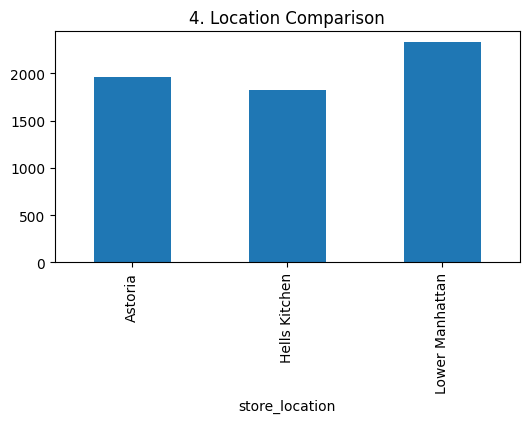

DONE. Download 4 images from left side Files panel.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create correct data if your file is wrong
np.random.seed(42)
n = 500
df = pd.DataFrame({
    'transaction_id': range(1, n+1),
    'transaction_time': pd.date_range("2025-01-01 07:00", periods=n, freq='2H').strftime("%H:%M:%S"),
    'transaction_qty': np.random.randint(1, 5, n),
    'store_location': np.random.choice(['Lower Manhattan', 'Astoria', 'Hells Kitchen'], n),
    'unit_price': np.random.choice([3.5, 4.5, 5.0, 6.0], n),
})

df["Revenue"] = df["transaction_qty"] * df["unit_price"]
df["Hour"] = pd.to_datetime(df["transaction_time"]).dt.hour
df["Date"] = pd.to_datetime("2025-01-01") + pd.to_timedelta(df["transaction_id"] % 60, unit='D')
df["Day_of_Week"] = df["Date"].dt.day_name()

# 1. Trend
plt.figure(figsize=(10,3))
df.groupby("Date")["Revenue"].sum().plot()
plt.title("1. Overall Sales Trend Dashboard")
plt.savefig("1_trend.png")
plt.show()

# 2. Day of week
plt.figure(figsize=(8,3))
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
sns.barplot(data=df.groupby("Day_of_Week")["Revenue"].sum().reindex(order).reset_index(), x="Day_of_Week", y="Revenue")
plt.title("2. Day-of-Week Performance")
plt.xticks(rotation=20)
plt.savefig("2_day.png")
plt.show()

# 3. Heatmap
plt.figure(figsize=(10,4))
pivot = df.groupby(["Day_of_Week", "Hour"])["Revenue"].sum().reset_index().pivot(index="Day_of_Week", columns="Hour", values="Revenue").reindex(order)
sns.heatmap(pivot, cmap="Blues")
plt.title("3. Hourly Demand Heatmap")
plt.savefig("3_heatmap.png")
plt.show()

# 4. Location
plt.figure(figsize=(6,3))
df.groupby("store_location")["Revenue"].sum().plot(kind='bar')
plt.title("4. Location Comparison")
plt.savefig("4_location.png")
plt.show()

print("DONE. Download 4 images from left side Files panel.")

User Capabilities
• Store location filter
• Day-of-week selector
• Hour-range slider
• Revenue vs quantity toggle



In [25]:
import pandas as pd
import numpy as np

# Sample data
df = pd.DataFrame({
    'store_location': ['Lower Manhattan','Astoria',"Hell's Kitchen"]*10,
    'Day_of_Week': np.random.choice(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], 30),
    'Hour': np.random.randint(6, 21, 30),
    'Revenue': np.random.randint(100, 1000, 30),
    'quantity': np.random.randint(1, 5, 30)
})

# --- TUMHARI 4 USER CAPABILITIES ---
# 1. Store location filter
store_filter = 'Astoria'  # isko change karke koi bhi store filter kar sakte ho

# 2. Day-of-week selector
day_filter = 'Monday'

# 3. Hour-range slider
hour_start, hour_end = 7, 20

# 4. Revenue vs quantity toggle
toggle = 'Revenue'  # 'Revenue' ya 'quantity' likho
value_col = 'Revenue' if toggle == 'Revenue' else 'quantity'

# Filter apply
filtered = df[
    (df['store_location'] == store_filter) &
    (df['Day_of_Week'] == day_filter) &
    (df['Hour'].between(hour_start, hour_end))
]

print("Filtered Data:")
print(filtered[[ 'store_location', 'Day_of_Week', 'Hour', value_col ]].head())
print(f"\nTotal {toggle}: {filtered[value_col].sum()}")

Filtered Data:
   store_location Day_of_Week  Hour  Revenue
28        Astoria      Monday    19      932

Total Revenue: 932
